# Bootstrap resampling — do the covariates actually affect reliability?

This replicates the **bootstrap resampling** analysis from the Jeong/Gondova
within-session reliability paper (what the lab loosely calls "permutation
testing"). It is the regression-robustness step, *not* a true permutation test.

**Procedure** — for each model `outcome ~ covariates`:
1. Fit the full-sample OLS (the point estimate).
2. Repeat 1,000×: resample the *subjects* with replacement, refit, store each coef.
3. Report per covariate: **β (full)**, **95% bootstrap CI** (excludes 0 → stable
   effect), and **directional consistency** = % of fits keeping the full-fit sign
   (the paper's headline; ~1.0 = robust, ~0.5 = noise).

> Bootstrap measures **stability**, not significance. A true permutation test
> (shuffle labels → null distribution → p-value) lives in the optional last section.

## Map to the paper's tables
| Paper | What it is | Where here |
|---|---|---|
| **Table 1** | *Descriptive* reliability (APD, ICC(2,1), RC) — "is it reproducible at all?" | **Section 0** |
| Table 2 | Regression β±SE, p (point estimates) | `beta_full` column |
| Supp. Table 1 | Bootstrap directional consistency, primary covariates | **Section 1** |
| Supp. Table 2 | Exploratory secondary covariates (slice-thickness) | **Section 2** (CNR/SNR/thk analog) |

## Covariate design
Paper's **4 primary covariates**: `GA`, `qa_mean`, `stack_count`, `qa_diff`
(quality difference). The **paper-4** model (Section 1) uses exactly these.
The subplate-specific extras (`cnr_mean`, `cnr_diff`, `sh_sp_diff`, `thk_mean`)
are *secondary/exploratory*; putting all 8 in one model is rank-deficient at
N=13–20, so each is screened one-at-a-time on the paper-4 base (Section 2).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.api as sm
from IPython.display import display

DATA = Path('../data')
ASSETS = Path('../assets')
ASSETS.mkdir(exist_ok=True)

GA_MAX = 32          # paper restricts to GA <= 32 weeks
N_BOOT = 1000        # bootstrap iterations (paper used 1000)

PAPER4 = ['GA', 'qa_mean', 'stack_count', 'qa_diff']   # faithful paper covariates
SP_EXTRAS = ['cnr_mean', 'cnr_diff', 'sh_sp_diff', 'thk_mean']  # secondary/exploratory
ID = ['subject_id', 'session_id']

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams['figure.dpi'] = 110

## Load data and build per-pair frames (all covariates merged in)

Two split pairs (S1-S2, S3-S4) are independent replications, fit separately.

In [2]:
raw = pd.read_csv(DATA / 'raw_subject_data.csv')
splits_df = pd.read_csv(DATA / 'split_comparision_data.csv')
iqm = pd.read_csv(DATA / 'image_quality_metrics.csv')
thk = pd.read_csv(DATA / 'thickness_audit.csv')

# GA <= 32 filter (drops late-GA subjects FCB070, FCB184, FCB187)
keep = raw.loc[raw['GA'] <= GA_MAX, ID]
raw = raw.merge(keep, on=ID, how='inner')
splits_df = splits_df.merge(keep, on=ID, how='inner')
iqm = iqm.merge(keep, on=ID, how='inner')
thk = thk.merge(keep, on=ID, how='inner')

# qa_diff per pair (paper's 'quality difference')
raw['qa_diff_S1S2'] = (raw['QA_S1'] - raw['QA_S2']).abs()
raw['qa_diff_S3S4'] = (raw['QA_S3'] - raw['QA_S4']).abs()

# sh_sp_diff per pair (subplate-mask homogeneity difference within the pair)
sh = iqm.pivot_table(index=ID, columns='split', values='snr_subplate').reset_index()
sh['sh_sp_diff_S1S2'] = (sh['S1'] - sh['S2']).abs()
sh['sh_sp_diff_S3S4'] = (sh['S3'] - sh['S4']).abs()


def build_pair(label):
    tag = label.replace('-', '')                 # 'S1S2'
    qcol = f'QA{tag[1] + tag[3]}_mean'           # 'QA12_mean'
    thk_pair = thk[thk['split_pair'] == label].drop_duplicates(ID)[ID + ['thk_mean']]
    return (
        splits_df[splits_df['split_pair'] == label]     # GA, cnr_mean, cnr_diff
        .merge(raw[ID + ['stack_count', qcol, f'qa_diff_{tag}']], on=ID, how='left')
        .merge(sh[ID + [f'sh_sp_diff_{tag}']], on=ID, how='left')
        .merge(thk_pair, on=ID, how='left')
        .rename(columns={qcol: 'qa_mean', f'qa_diff_{tag}': 'qa_diff',
                         f'sh_sp_diff_{tag}': 'sh_sp_diff'})
    )


s12, s34 = build_pair('S1-S2'), build_pair('S3-S4')


def build_thk(label):
    base = (thk[thk['split_pair'] == label]
            .drop_duplicates(ID).dropna(subset=['thk_diff']).reset_index(drop=True))
    return base.merge(build_pair(label)[ID + ['qa_diff', 'cnr_mean', 'cnr_diff',
                                              'sh_sp_diff']], on=ID, how='left')


thk_s12, thk_s34 = build_thk('S1-S2'), build_thk('S3-S4')
print('volume/surface N — S1-S2:', len(s12), '| S3-S4:', len(s34))
print('thickness    N  — S1-S2:', len(thk_s12), '| S3-S4:', len(thk_s34))

volume/surface N — S1-S2: 20 | S3-S4: 20
thickness    N  — S1-S2: 13 | S3-S4: 13


## Section 0 — Table 1: descriptive reliability (APD + ICC(2,1) + RC)

This is the **first** question — *does each metric agree with itself across the
two splits?* — and it must hold before the covariate analysis means anything.

Plain-language reading:
- **ICC(2,1)** — intraclass correlation, two-way random effects, *absolute
  agreement*, single measurement (computed with `pingouin.intraclass_corr`,
  the `ICC2` row). Scale 0→1: how much of the variation is real between-subject
  differences vs. measurement noise. **>0.90 = excellent, >0.75 = good.** The
  two "raters" are the two splits of a pair.
- **RC** (repeatability coefficient) — `1.96 × SD(split1 − split2)`, in the
  metric's own units. *The difference between two splits of the same fetus will
  be smaller than RC about 95% of the time.* Smaller = tighter.

CIs: ICC uses pingouin's **analytic** 95% CI (the standard exact interval); RC
uses subject-level **bootstrap** (1,000 iters), matching how the paper estimated
RC CIs. Computed on the **same GA≤32 sample** as the models.

Per-split paired sources (M1, M2): SP volume → `native_vol_sp`; WM surface →
`wm_surface_area` (both in `image_quality_metrics.csv`); SP thickness →
`wholebrain_thk_mean` (`thickness_audit.csv`).

Results are written back into the **existing** `assets/reliability_summary_table.csv`
as new `icc21*`/`rc*` columns — no new file. (Note: `paper_models.ipynb`
regenerates that CSV with APD only, so run this section *after* it, or these
columns get overwritten.)

In [3]:
def icc21(M, ids):
    """ICC(2,1) + analytic 95% CI via pingouin.

    Two-way random effects, single measurement, absolute agreement. The two
    'raters' are the two splits of a pair. Returns (icc, ci_lo, ci_hi).
    """
    long = pd.DataFrame({
        'subject': np.repeat(np.asarray(ids), 2),
        'split': np.tile(['A', 'B'], len(M)),
        'value': M.reshape(-1),                      # row-major: [s0A, s0B, s1A, ...]
    })
    # ICC(A,1) = two-way random, absolute agreement, single measurement = ICC(2,1)
    r = pg.intraclass_corr(data=long, targets='subject', raters='split',
                           ratings='value').set_index('Type').loc['ICC(A,1)']
    return r['ICC'], r['CI95'][0], r['CI95'][1]


def rc_coef(M):
    """Repeatability coefficient = 1.96 * SD of signed split-to-split differences."""
    return 1.96 * (M[:, 0] - M[:, 1]).std(ddof=1)


def _boot_ci(M, fn, n_boot=N_BOOT, seed=0):
    """Subject-level bootstrap percentile CI (used for RC; pingouin has no RC)."""
    rng = np.random.default_rng(seed)
    n = len(M)
    vals = np.array([fn(M[rng.integers(0, n, n)]) for _ in range(n_boot)])
    return np.percentile(vals, [2.5, 97.5])


# metric label (must match reliability_summary_table.csv) -> (source df, per-split col)
TABLE1_SRC = [
    ('SP volume (mm³)',      iqm, 'native_vol_sp'),
    ('WM surface area (mm²)', iqm, 'wm_surface_area'),
    ('WB SP thickness (mm)',  thk, 'wholebrain_thk_mean'),
]

rows = []
for metric, src, val in TABLE1_SRC:
    piv = src.pivot_table(index=ID, columns='split', values=val)
    for s1, s2, pair in [('S1', 'S2', 'S1-S2'), ('S3', 'S4', 'S3-S4')]:
        sub = piv[[s1, s2]].dropna()
        M = sub.values
        icc, icc_lo, icc_hi = icc21(M, range(len(sub)))   # analytic CI
        rc_lo, rc_hi = _boot_ci(M, rc_coef)               # bootstrap CI (paper's method)
        rows.append({'metric': metric, 'pair': pair, 'N_pairs': len(M),
                     'icc21': icc, 'icc_lo': icc_lo, 'icc_hi': icc_hi,
                     'rc': rc_coef(M), 'rc_lo': rc_lo, 'rc_hi': rc_hi})
icc_rc = pd.DataFrame(rows)

# Augment the EXISTING reliability table (no new CSV)
RELI = ASSETS / 'reliability_summary_table.csv'
new_cols = ['N_pairs', 'icc21', 'icc_lo', 'icc_hi', 'rc', 'rc_lo', 'rc_hi']
if RELI.exists():
    base = pd.read_csv(RELI).drop(columns=new_cols, errors='ignore')
    merged = base.merge(icc_rc, on=['metric', 'pair'], how='left')
    merged.to_csv(RELI, index=False)
    print('Augmented', RELI.name, 'with ICC(2,1) + RC columns')
    display(merged[['metric', 'pair', 'N', 'APD_mean',
                    'icc21', 'icc_lo', 'icc_hi', 'rc', 'rc_lo', 'rc_hi']])
else:
    print('WARNING:', RELI.name, 'not found — run paper_models.ipynb first.')
    display(icc_rc)

Augmented reliability_summary_table.csv with ICC(2,1) + RC columns


,metric,pair,N,APD_mean,icc21,icc_lo,icc_hi,rc,rc_lo,rc_hi
0,SP volume (mm³),S1-S2,20,1.6300,0.9970,0.9900,1.0000,1460.3369,900.8601,1898.6573
1,SP volume (mm³),S3-S4,20,1.2600,0.9972,0.9900,1.0000,1378.7107,803.1169,1808.9869
2,WM surface area (mm²),S1-S2,20,1.0500,0.9967,0.9900,1.0000,844.0597,210.9166,1237.0843
3,WM surface area (mm²),S3-S4,20,0.6100,0.9995,1.0000,1.0000,358.2384,182.0101,520.5348
4,WB SP thickness (mm),S1-S2,13,3.7000,0.9591,0.8700,0.9900,0.3552,0.1164,0.5097
5,WB SP thickness (mm),S3-S4,13,5.1900,0.8587,0.6000,0.9500,0.5564,0.1457,0.8199


## ⚠️ Caveats — read before interpreting the covariate sections

1. **N and predictor count, not covariate "nature", are the real constraint.**
   At N=13–20 every added covariate costs a degree of freedom and widens the
   bootstrap CIs — hence one-at-a-time screening in Section 2.
2. **`thk_mean` is subplate *cortical* thickness, NOT acquisition slice thickness.**
   The paper's secondary thickness covariate was MRI slice thickness (2–4 mm).
   Ours is a morphometric output that tracks GA → collinear with GA, and
   **excluded from the thickness-outcome model** (predicting `thk_diff` from
   `thk_mean` is circular).
3. **`cnr_*` / `sh_sp_diff` are objective quality measures the paper lacked**
   (`cnr_mean` ≈ objective `qa_mean`; `cnr_diff`/`sh_sp_diff` ≈ objective `qa_diff`).

## The bootstrap (with a rank guard for small-N resamples)

In [4]:
def bootstrap_ols(df, outcome, predictors, n_boot=N_BOOT, seed=0):
    """Subject-level bootstrap of an OLS fit. Returns (summary_df, full_fit, draws)."""
    sub = df[[outcome] + predictors].dropna().reset_index(drop=True)
    X = sm.add_constant(sub[predictors])
    y = sub[outcome]
    full = sm.OLS(y, X).fit()
    names = list(X.columns)

    rng = np.random.default_rng(seed)
    n, k = len(sub), X.shape[1]
    draws = np.full((n_boot, k), np.nan)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)                      # resample WITH replacement
        Xb, yb = X.iloc[idx], y.iloc[idx]
        if np.linalg.matrix_rank(Xb.values) < k:          # skip rank-deficient draw
            continue
        try:
            draws[b] = sm.OLS(yb, Xb).fit().params.reindex(names).values
        except Exception:
            pass
    draws = draws[~np.isnan(draws).any(axis=1)]

    rows = []
    for j, name in enumerate(names):
        col = draws[:, j]
        beta = full.params[name]
        lo, hi = np.percentile(col, [2.5, 97.5])
        frac_pos = np.mean(col > 0)
        rows.append({
            'term': name, 'beta_full': beta, 'boot_mean': col.mean(),
            'ci_low': lo, 'ci_high': hi,
            'dir_consistency': np.mean(np.sign(col) == np.sign(beta)),
            'ci_excludes_0': bool(lo > 0 or hi < 0),
            'p_boot': 2 * min(frac_pos, 1 - frac_pos),
        })
    summary = pd.DataFrame(rows).set_index('term')
    summary.attrs.update(n=n, k=k, valid_draws=len(draws),
                         resid_df=int(full.df_resid), r2=full.rsquared)
    return summary, full, draws

## Section 1 — Paper-4 model (faithful replication), all three outcomes

`outcome ~ GA + qa_mean + stack_count + qa_diff`, fit separately per pair.
Compare against the paper's logic — esp. the expectation that `qa_diff`
directional consistency sits near chance.

**How to read each row** — `beta_full`: slope from the single full fit (sign +
"is it ~0" matter, not magnitude). `dir_consistency`: fraction of 1,000 refits
keeping that sign (1.0 robust, 0.5 noise). `ci_excludes_0`: the 95% bootstrap
spread is entirely one side of 0 → stable effect. Trust a covariate only if it
agrees **across both pairs**.

In [5]:
MODELS = [
    ('SP volume diff',      'abs_diff_sp',          s12,     s34),
    ('WM surface-area diff', 'wm_surface_area_diff', s12,     s34),
    ('WB SP thickness diff', 'thk_diff',             thk_s12, thk_s34),
]

paper4_summaries = {}
for out_label, out_col, f12, f34 in MODELS:
    for pair, frame in [('S1-S2', f12), ('S3-S4', f34)]:
        summ, full, _ = bootstrap_ols(frame, out_col, PAPER4)
        key = f'{out_label} | {pair}'
        paper4_summaries[key] = summ
        print(f'\n=== {key}  (N={summ.attrs["n"]}, resid_df={summ.attrs["resid_df"]}, '
              f'R²={summ.attrs["r2"]:.3f}, valid draws={summ.attrs["valid_draws"]}) ===')
        display(summ.drop(index='const'))

pd.concat({k: v.drop(index='const') for k, v in paper4_summaries.items()},
          names=['model', 'term']).to_csv(ASSETS / 'bootstrap_paper4_summary.csv')
print('\nSaved → assets/bootstrap_paper4_summary.csv')


=== SP volume diff | S1-S2  (N=20, resid_df=15, R²=0.288, valid draws=1000) ===


,beta_full,boot_mean,ci_low,ci_high,dir_consistency,ci_excludes_0,p_boot
term,,,,,,,
GA,97.6114,88.2211,-37.9265,203.9041,0.9290,False,0.1420
qa_mean,-937.4143,-942.0309,-2372.4197,731.6631,0.8990,False,0.2020
stack_count,12.0373,15.1680,-79.8821,100.7754,0.6480,False,0.7040
qa_diff,-577.0449,-366.9057,-3588.4655,3472.9499,0.6050,False,0.7900



=== SP volume diff | S3-S4  (N=20, resid_df=15, R²=0.362, valid draws=1000) ===


,beta_full,boot_mean,ci_low,ci_high,dir_consistency,ci_excludes_0,p_boot
term,,,,,,,
GA,114.9782,118.9017,14.5023,226.4968,0.9860,True,0.0280
qa_mean,766.6764,840.7883,-727.9913,2538.1642,0.8910,False,0.2180
stack_count,56.7896,56.3637,-12.4449,123.4266,0.9460,False,0.1080
qa_diff,2936.1434,2149.3619,-4913.1211,7104.3698,0.7500,False,0.5000



=== WM surface-area diff | S1-S2  (N=20, resid_df=15, R²=0.184, valid draws=1000) ===


...


=== WB SP thickness diff | S1-S2  (N=13, resid_df=8, R²=0.421, valid draws=1000) ===


,beta_full,boot_mean,ci_low,ci_high,dir_consistency,ci_excludes_0,p_boot
term,,,,,,,
GA,0.0402,0.0399,-0.0024,0.1093,0.9430,False,0.1140
qa_mean,-0.2596,-0.1291,-1.2607,1.1350,0.5830,False,0.8340
stack_count,-0.0177,-0.0161,-0.0807,0.0371,0.7250,False,0.5500
qa_diff,-0.5469,-0.4638,-1.9697,0.9417,0.6960,False,0.6080



=== WB SP thickness diff | S3-S4  (N=13, resid_df=8, R²=0.381, valid draws=1000) ===


,beta_full,boot_mean,ci_low,ci_high,dir_consistency,ci_excludes_0,p_boot
term,,,,,,,
GA,0.0443,0.0552,-0.0127,0.1634,0.9440,False,0.1120
qa_mean,-0.2562,-0.1376,-1.4853,0.9838,0.6220,False,0.7560
stack_count,-0.0227,-0.0269,-0.0970,0.0202,0.8510,False,0.2980
qa_diff,-1.5868,-1.6787,-7.1158,3.6367,0.7920,False,0.4160



Saved → assets/bootstrap_paper4_summary.csv


In [ ]:
# ===== Section 1 (combined) — one dataframe per metric, studies stacked (S1-S2 over S3-S4) =====
# Same numbers as the per-pair tables above, regrouped: each common metric shows
# S1-S2 on top of S3-S4. Row MultiIndex = (pair, term); a LaTeX table is emitted
# per metric via pandas Styler.to_latex.
METRICS = ['SP volume diff', 'WM surface-area diff', 'WB SP thickness diff']
PAIRS = ['S1-S2', 'S3-S4']


def _fmt(v):
    if isinstance(v, bool):
        return str(v)
    if isinstance(v, (int, float)):
        return f'{v:.4f}'
    return str(v)


paper4_combined = {}
for metric in METRICS:
    parts = {pair: paper4_summaries[f'{metric} | {pair}'].drop(index='const')
             for pair in PAIRS}
    combined = pd.concat(parts, axis=0)              # row MultiIndex: (pair, term) -> S1-S2 over S3-S4
    combined.index.names = ['pair', 'term']
    paper4_combined[metric] = combined
    ns = {p: paper4_summaries[f'{metric} | {p}'].attrs['n'] for p in PAIRS}
    print(f'\n=== {metric}  (N: ' + ', '.join(f'{p}={ns[p]}' for p in PAIRS) + ') ===')
    display(combined)

    # --- LaTeX via pandas Styler ---
    sty = (combined.style
           .format(_fmt)
           .format_index(escape='latex', axis=1)
           .format_index(escape='latex', axis=0))
    latex = sty.to_latex(hrules=True, position='ht', position_float='centering',
                         multicol_align='c', clines='skip-last;data',
                         caption=f'Paper-4 bootstrap OLS — {metric} (S1-S2 over S3-S4).')
    print('\n--- LaTeX (Styler.to_latex) ---\n' + latex)



=== SP volume diff  (N: S1-S2=20, S3-S4=20) ===


beta_full  boot_mean     ci_low   ci_high  dir_consistency  \
pair  term                                                                      
S1-S2 GA             97.6114    88.2211   -37.9265  203.9041           0.9290   
      qa_mean      -937.4143  -942.0309 -2372.4197  731.6631           0.8990   
      stack_count    12.0373    15.1680   -79.8821  100.7754           0.6480   
      qa_diff      -577.0449  -366.9057 -3588.4655 3472.9499           0.6050   
S3-S4 GA            114.9782   118.9017    14.5023  226.4968           0.9860   
      qa_mean       766.6764   840.7883  -727.9913 2538.1642           0.8910   
      stack_count    56.7896    56.3637   -12.4449  123.4266           0.9460   
      qa_diff      2936.1434  2149.3619 -4913.1211 7104.3698           0.7500   

                   ci_excludes_0  p_boot  
pair  term                                
S1-S2 GA                   False  0.1420  
      qa_mean              False  0.2020  
      stack_count          False  0.7040  
      qa_diff              False  0.7900  
S3-S4 GA                    True  0.0280  
      qa_mean              False  0.2180  
      stack_count          False  0.1080  
      qa_diff              False  0.5000


--- LaTeX (Styler.to_latex) ---
\begin{table}[ht]
\centering
\caption{Paper-4 bootstrap OLS — SP volume diff (S1-S2 over S3-S4).}
\begin{tabular}{llrrrrrrr}
\toprule
 &  & beta\_full & boot\_mean & ci\_low & ci\_high & dir\_consistency & ci\_excludes\_0 & p\_boot \\
pair & term &  &  &  &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{S1-S2} & GA & 97.6114 & 88.2211 & -37.9265 & 203.9041 & 0.9290 & False & 0.1420 \\
 & qa\_mean & -937.4143 & -942.0309 & -2372.4197 & 731.6631 & 0.8990 & False & 0.2020 \\
 & stack\_count & 12.0373 & 15.1680 & -79.8821 & 100.7754 & 0.6480 & False & 0.7040 \\
 & qa\_diff & -577.0449 & -366.9057 & -3588.4655 & 3472.9499 & 0.6050 & False & 0.7900 \\
\cline{1-9}
\multirow[c]{4}{*}{S3-S4} & GA & 114.9782 & 118.9017 & 14.5023 & 226.4968 & 0.9860 & True & 0.0280 \\
 & qa\_mean & 766.6764 & 840.7883 & -727.9913 & 2538.1642 & 0.8910 & False & 0.2180 \\
 & stack\_count & 56.7896 & 56.3637 & -12.4449 & 123.4266 & 0.9460 & False & 0.1080 \\
 & qa\_diff & 2936.1434 & 2149.

beta_full  boot_mean     ci_low   ci_high  dir_consistency  \
pair  term                                                                      
S1-S2 GA             34.8310    38.8800   -37.7314  161.2451           0.7880   
      qa_mean      -265.4615  -272.0370 -1823.2026 1059.8684           0.6730   
      stack_count   -47.4825   -51.0463  -121.2683   16.0130           0.9230   
      qa_diff     -1349.4083 -1329.9561 -3973.4728  759.2385           0.9010   
S3-S4 GA             13.5977    15.6465    -7.8713   40.7074           0.9080   
      qa_mean      -499.0086  -474.1174 -1033.8039  -15.1341           0.9790   
      stack_count   -28.9038   -28.4358   -53.7285    0.7420           0.9690   
      qa_diff     -1131.1447 -1220.6773 -2708.2214  -45.7435           0.9830   

                   ci_excludes_0  p_boot  
pair  term                                
S1-S2 GA                   False  0.4240  
      qa_mean              False  0.6540  
      stack_count          False  0.1540  
      qa_diff              False  0.1980  
S3-S4 GA                   False  0.1840  
      qa_mean               True  0.0420  
      stack_count          False  0.0620  
      qa_diff               True  0.0340


--- LaTeX (Styler.to_latex) ---
\begin{table}[ht]
\centering
\caption{Paper-4 bootstrap OLS — WM surface-area diff (S1-S2 over S3-S4).}
\begin{tabular}{llrrrrrrr}
\toprule
 &  & beta\_full & boot\_mean & ci\_low & ci\_high & dir\_consistency & ci\_excludes\_0 & p\_boot \\
pair & term &  &  &  &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{S1-S2} & GA & 34.8310 & 38.8800 & -37.7314 & 161.2451 & 0.7880 & False & 0.4240 \\
 & qa\_mean & -265.4615 & -272.0370 & -1823.2026 & 1059.8684 & 0.6730 & False & 0.6540 \\
 & stack\_count & -47.4825 & -51.0463 & -121.2683 & 16.0130 & 0.9230 & False & 0.1540 \\
 & qa\_diff & -1349.4083 & -1329.9561 & -3973.4728 & 759.2385 & 0.9010 & False & 0.1980 \\
\cline{1-9}
\multirow[c]{4}{*}{S3-S4} & GA & 13.5977 & 15.6465 & -7.8713 & 40.7074 & 0.9080 & False & 0.1840 \\
 & qa\_mean & -499.0086 & -474.1174 & -1033.8039 & -15.1341 & 0.9790 & True & 0.0420 \\
 & stack\_count & -28.9038 & -28.4358 & -53.7285 & 0.7420 & 0.9690 & False & 0.0620 \\
 & qa\_diff & -1131.14

beta_full  boot_mean  ci_low  ci_high  dir_consistency  \
pair  term                                                                  
S1-S2 GA              0.0402     0.0399 -0.0024   0.1093           0.9430   
      qa_mean        -0.2596    -0.1291 -1.2607   1.1350           0.5830   
      stack_count    -0.0177    -0.0161 -0.0807   0.0371           0.7250   
      qa_diff        -0.5469    -0.4638 -1.9697   0.9417           0.6960   
S3-S4 GA              0.0443     0.0552 -0.0127   0.1634           0.9440   
      qa_mean        -0.2562    -0.1376 -1.4853   0.9838           0.6220   
      stack_count    -0.0227    -0.0269 -0.0970   0.0202           0.8510   
      qa_diff        -1.5868    -1.6787 -7.1158   3.6367           0.7920   

                   ci_excludes_0  p_boot  
pair  term                                
S1-S2 GA                   False  0.1140  
      qa_mean              False  0.8340  
      stack_count          False  0.5500  
      qa_diff              False  0.6080  
S3-S4 GA                   False  0.1120  
      qa_mean              False  0.7560  
      stack_count          False  0.2980  
      qa_diff              False  0.4160


--- LaTeX (Styler.to_latex) ---
\begin{table}[ht]
\centering
\caption{Paper-4 bootstrap OLS — WB SP thickness diff (S1-S2 over S3-S4).}
\begin{tabular}{llrrrrrrr}
\toprule
 &  & beta\_full & boot\_mean & ci\_low & ci\_high & dir\_consistency & ci\_excludes\_0 & p\_boot \\
pair & term &  &  &  &  &  &  &  \\
\midrule
\multirow[c]{4}{*}{S1-S2} & GA & 0.0402 & 0.0399 & -0.0024 & 0.1093 & 0.9430 & False & 0.1140 \\
 & qa\_mean & -0.2596 & -0.1291 & -1.2607 & 1.1350 & 0.5830 & False & 0.8340 \\
 & stack\_count & -0.0177 & -0.0161 & -0.0807 & 0.0371 & 0.7250 & False & 0.5500 \\
 & qa\_diff & -0.5469 & -0.4638 & -1.9697 & 0.9417 & 0.6960 & False & 0.6080 \\
\cline{1-9}
\multirow[c]{4}{*}{S3-S4} & GA & 0.0443 & 0.0552 & -0.0127 & 0.1634 & 0.9440 & False & 0.1120 \\
 & qa\_mean & -0.2562 & -0.1376 & -1.4853 & 0.9838 & 0.6220 & False & 0.7560 \\
 & stack\_count & -0.0227 & -0.0269 & -0.0970 & 0.0202 & 0.8510 & False & 0.2980 \\
 & qa\_diff & -1.5868 & -1.6787 & -7.1158 & 3.6367 & 0.7920 & False

## Section 2 — SP-specific covariate screening (exploratory, one at a time)

The Supp.-Table-2 analog. Each extra covariate is added singly to the paper-4
base; only its own row is reported. `thk_mean` is skipped for the thickness
outcome (circular). Watch `N` — `thk_mean`/`sh_sp_diff` shrink it. A covariate
earns attention only if it clears `ci_excludes_0` in **both** pairs.

In [6]:
screen_rows = []
for out_label, out_col, f12, f34 in MODELS:
    for pair, frame in [('S1-S2', f12), ('S3-S4', f34)]:
        for extra in SP_EXTRAS:
            if extra == 'thk_mean' and out_col == 'thk_diff':
                continue                                   # circular — skip
            summ, _, _ = bootstrap_ols(frame, out_col, PAPER4 + [extra])
            r = summ.loc[extra].to_dict()
            r.update(outcome=out_label, pair=pair, covariate=extra,
                     N=summ.attrs['n'], resid_df=summ.attrs['resid_df'])
            screen_rows.append(r)

screen = pd.DataFrame(screen_rows).set_index(['outcome', 'pair', 'covariate'])[
    ['N', 'resid_df', 'beta_full', 'ci_low', 'ci_high',
     'dir_consistency', 'ci_excludes_0', 'p_boot']]
screen.to_csv(ASSETS / 'bootstrap_sp_covariate_screen.csv')
display(screen)
print('\nSaved → assets/bootstrap_sp_covariate_screen.csv')

N  resid_df   beta_full       ci_low  \
outcome              pair  covariate                                           
SP volume diff       S1-S2 cnr_mean    20        14  25765.5334  -27163.3440   
                           cnr_diff    20        14  98896.2095 -213994.5742   
                           sh_sp_diff  20        14    765.5091      73.2196   
                           thk_mean    13         7   -392.0985   -1101.1449   
                     S3-S4 cnr_mean    20        14 -14279.1940 -162158.5826   
                           cnr_diff    20        14 -33168.5068 -153706.8091   
                           sh_sp_diff  20        14     96.6021   -1138.5861   
                           thk_mean    13         7   -119.3766   -3269.2542   
WM surface-area diff S1-S2 cnr_mean    20        14  14199.4022  -87638.5890   
                           cnr_diff    20        14  75576.9938 -149076.3673   
                           sh_sp_diff  20        14   -144.6501    -733.7182   
                           thk_mean    13         7   -115.1341    -425.6766   
                     S3-S4 cnr_mean    20        14  12804.5525    -935.5729   
                           cnr_diff    20        14 -23295.6940  -63240.4071   
                           sh_sp_diff  20        14     43.3947    -208.3222   
                           thk_mean    13         7     51.4280    -263.5816   
WB SP thickness diff S1-S2 cnr_mean    13         7     -4.6328     -80.4992   
                           cnr_diff    13         7    -12.2871    -336.5592   
                           sh_sp_diff  13         7      0.0528      -0.2486   
                     S3-S4 cnr_mean    13         7      7.9029    -134.0280   
                           cnr_diff    13         7    -15.9712    -166.1243   
                           sh_sp_diff  13         7     -0.4477      -1.2343   

                                          ci_high  dir_consistency  \
outcome              pair  covariate                                 
SP volume diff       S1-S2 cnr_mean   181999.2442           0.8420   
                           cnr_diff   303404.3236           0.7890   
                           sh_sp_diff   1615.5363           0.9860   
                           thk_mean     1075.3954           0.8597   
                     S3-S4 cnr_mean    47743.9033           0.7430   
                           cnr_diff   182609.6182           0.6260   
                           sh_sp_diff   1447.9056           0.5090   
                           thk_mean     1591.3729           0.6723   
WM surface-area diff S1-S2 cnr_mean    73270.8280           0.7810   
                           cnr_diff   339253.6068           0.8220   
                           sh_sp_diff    410.6505           0.7180   
                           thk_mean      306.5259           0.8186   
                     S3-S4 cnr_mean    48025.3528           0.9590   
                           cnr_diff    28935.9258           0.7270   
                           sh_sp_diff    341.2500           0.6010   
                           thk_mean      332.2157           0.5792   
WB SP thickness diff S1-S2 cnr_mean       39.5594           0.7054   
                           cnr_diff      219.4066           0.5832   
                           sh_sp_diff      0.8652           0.7625   
                     S3-S4 cnr_mean      189.3781           0.6463   
                           cnr_diff      285.7375           0.5872   
                           sh_sp_diff      0.2402           0.9208   

                                       ci_excludes_0  p_boot  
outcome              pair  covariate                          
SP volume diff       S1-S2 cnr_mean            False  0.3160  
                           cnr_diff            False  0.4220  
                           sh_sp_diff           True  0.0280  
                           thk_mean            False  0.2806  
                     S3-S4 cnr_mean            False  0.5140


Saved → assets/bootstrap_sp_covariate_screen.csv


## Section 3 — Plot: paper-4 coefficient distributions (β, 95% CI, sign)

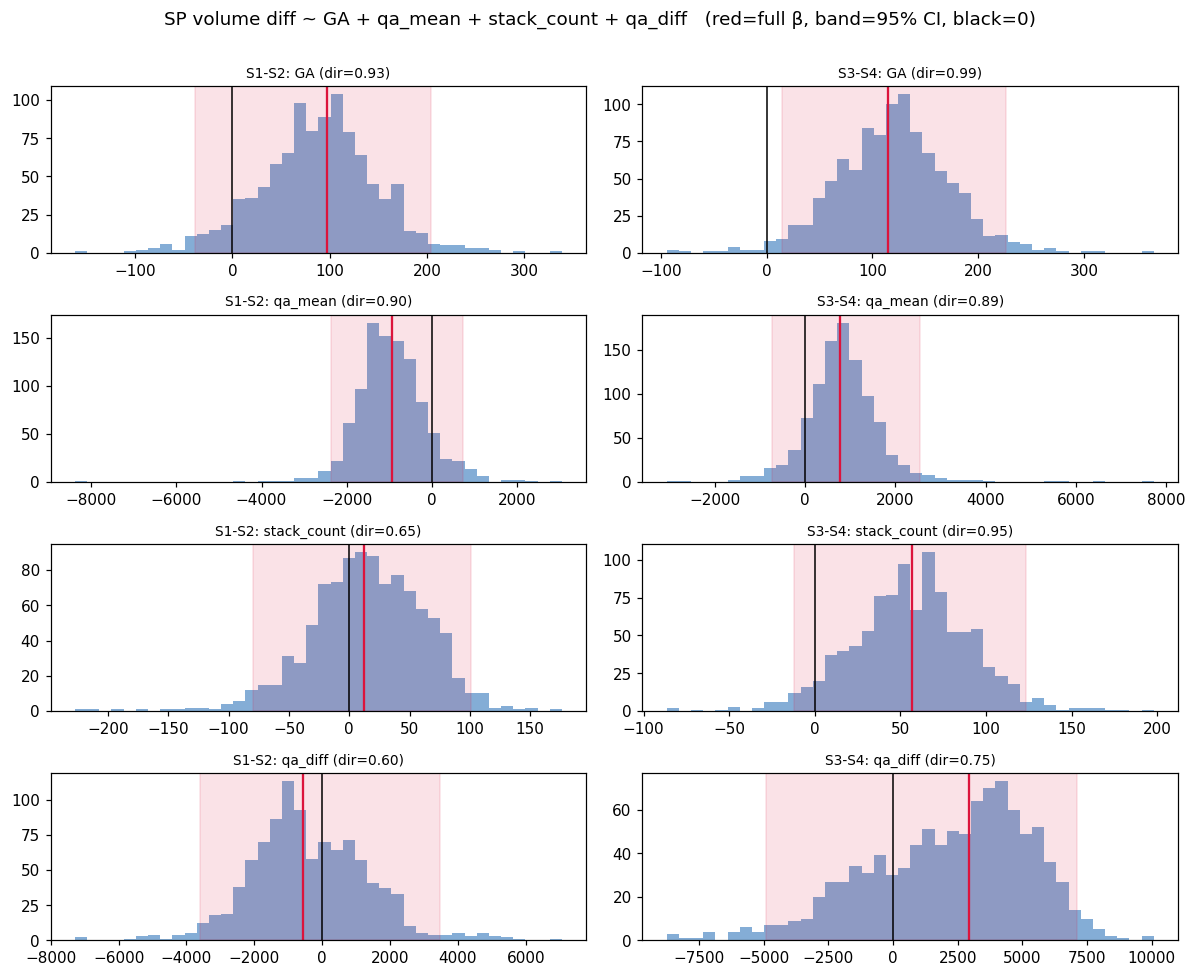

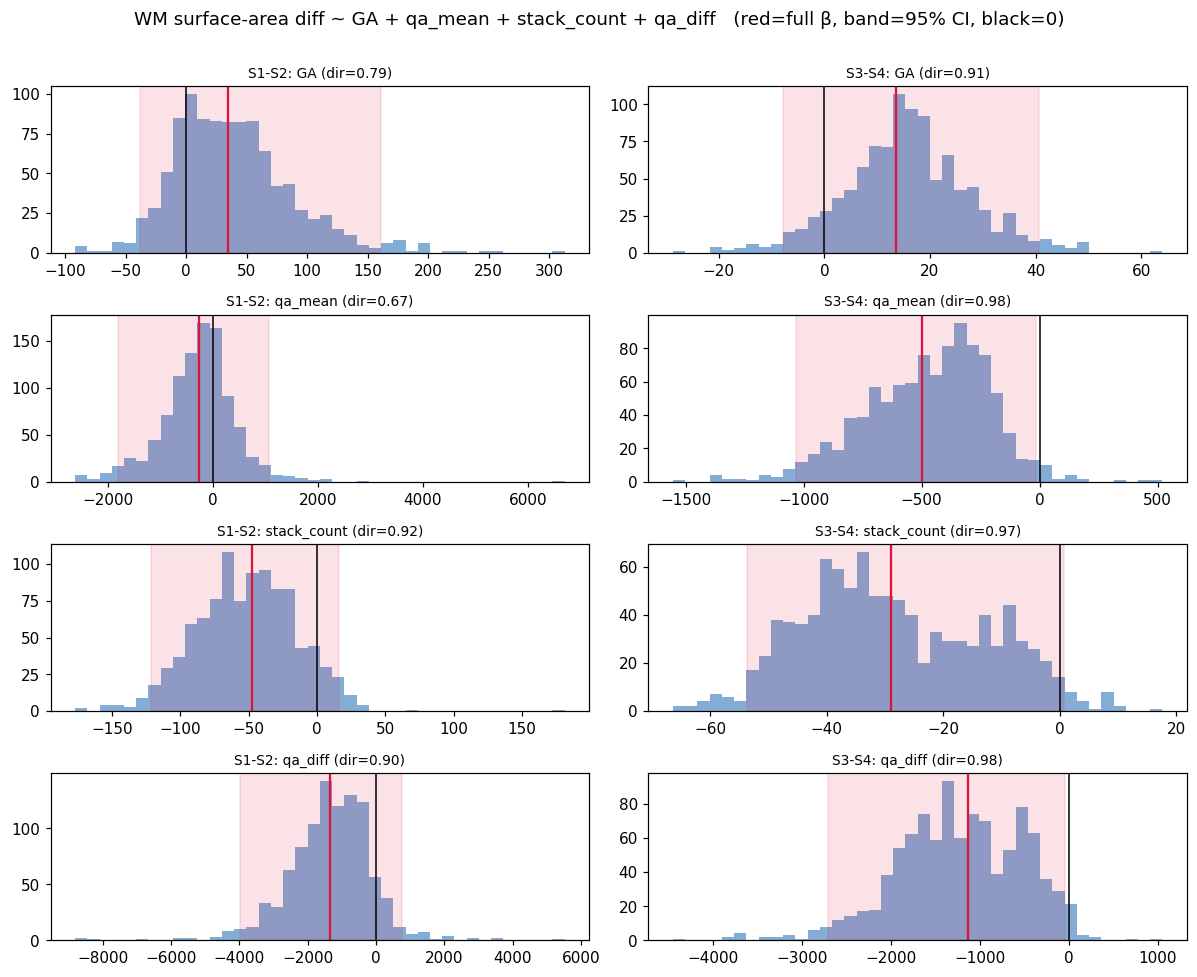

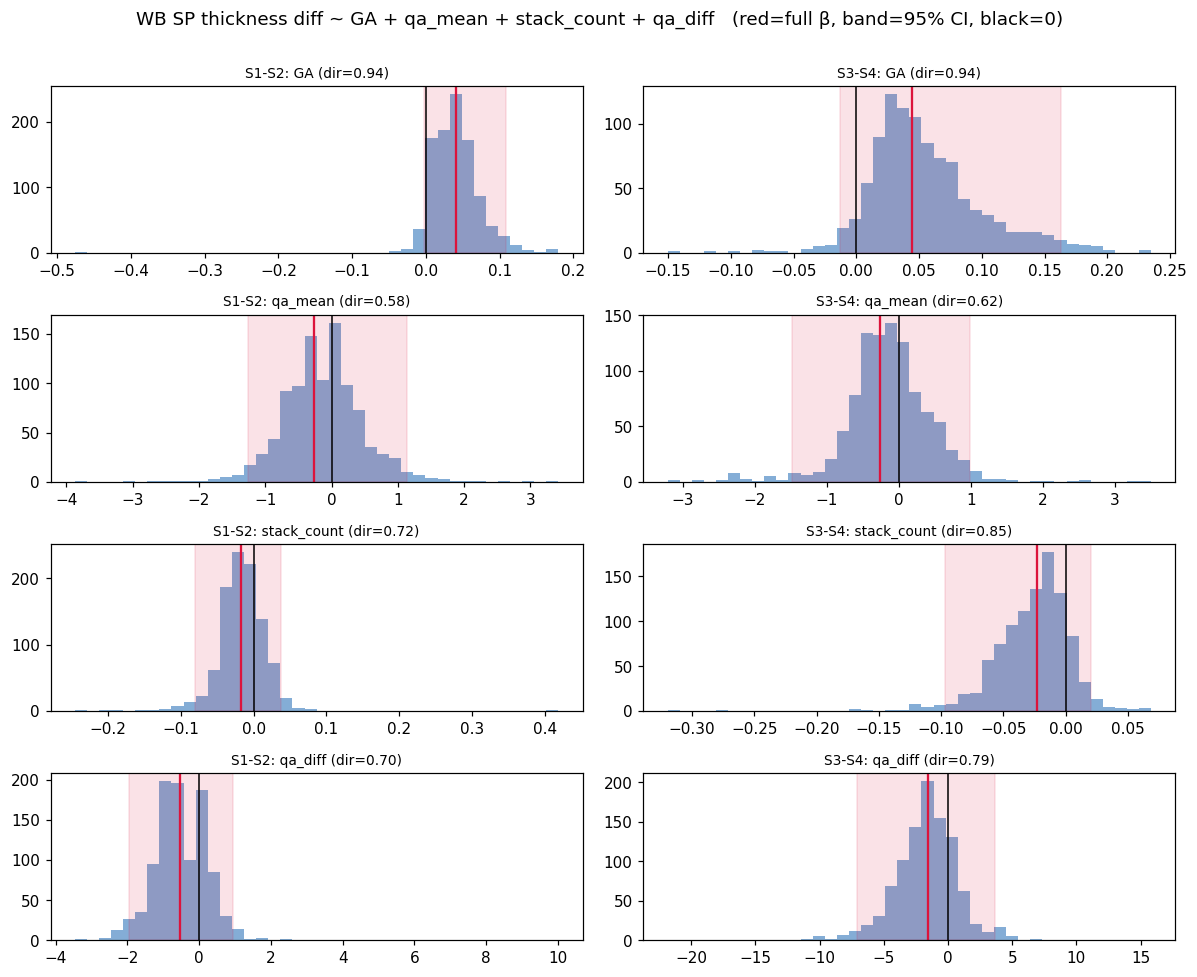

In [7]:
def plot_bootstrap(out_label, out_col, f12, f34, predictors=PAPER4):
    fig, axes = plt.subplots(len(predictors), 2,
                             figsize=(11, 2.2 * len(predictors)), squeeze=False)
    for col_i, (pair, frame) in enumerate([('S1-S2', f12), ('S3-S4', f34)]):
        summ, _, draws = bootstrap_ols(frame, out_col, predictors)
        names = ['const'] + predictors
        for row_i, term in enumerate(predictors):
            ax = axes[row_i][col_i]
            ax.hist(draws[:, names.index(term)], bins=40, color='#6699cc', alpha=0.8)
            ax.axvline(0, color='k', lw=1)
            ax.axvline(summ.loc[term, 'beta_full'], color='crimson', lw=1.5)
            ax.axvspan(summ.loc[term, 'ci_low'], summ.loc[term, 'ci_high'],
                       color='crimson', alpha=0.12)
            ax.set_title(f'{pair}: {term} (dir={summ.loc[term, "dir_consistency"]:.2f})',
                         fontsize=9)
    fig.suptitle(f'{out_label} ~ {" + ".join(predictors)}   '
                 '(red=full β, band=95% CI, black=0)', y=1.004)
    fig.tight_layout()
    plt.show()


for out_label, out_col, f12, f34 in MODELS:
    plot_bootstrap(out_label, out_col, f12, f34)

## Section 4 — Paper-shaped tables for slides

Reshaped to match the original paper for at-a-glance comparison. **Dependent
variable = APD (% difference)**, matching the paper's Table 2 and the project's
APD convention ([[reliability_metric_correction]]). Sections 1–3 use the raw
absolute difference, so their directional-consistency numbers differ — **these
APD tables are the slide-ready, paper-comparable ones.**

- **Table 1** — within-session reliability (APD, ICC(2,1), RC); metrics × studies.
- **Table 2 analog** — APD ~ covariates: `β ± SE (p)`; covariates as columns,
  study/metric as rows. `*` = uncorrected p<0.05.
- **Supplementary Table 1 analog** — bootstrap **directional consistency (%)**,
  same shape: one percentage per covariate column (the per-column-per-covariate
  view you asked for).

Each prints as a rendered DataFrame and **LaTeX** (booktabs)
for copy-paste into the slideshow.

In [8]:
# ===== Section 4 — paper-shaped tables for slides =====
# Dependent variable = APD (% difference): matches the paper's Table 2 and the
# project's APD convention. Sections 1-3 above use the raw absolute difference,
# so their directional-consistency numbers differ — THESE are the paper-comparable
# ones for the slideshow.

# APD outcome columns
for _f in (s12, s34):
    _f['apd_sp'] = _f['rel_diff_sp']
    _f['apd_surface'] = _f['wm_surface_area_diff'] / _f['wm_surface_area_mean'] * 100
# thk frames already carry apd_thk

APD_MODELS = [
    ('SP Volume',    'apd_sp',      s12,     s34),
    ('Surface Area', 'apd_surface', s12,     s34),
    ('SP Thickness', 'apd_thk',     thk_s12, thk_s34),
]
COV_LABELS = {'qa_mean': 'Mean Stack Quality', 'qa_diff': 'Quality Difference',
              'stack_count': 'Stack Count', 'GA': 'GA'}
COV_ORDER = ['Mean Stack Quality', 'Quality Difference', 'Stack Count', 'GA']
STUDY = {'S1-S2': 'Study 1 (S1–S2)', 'S3-S4': 'Study 2 (S3–S4)'}
METRIC_ORDER = ['SP Volume', 'Surface Area', 'SP Thickness']

recs = []
for metric, ycol, f12, f34 in APD_MODELS:
    for pair, frame in [('S1-S2', f12), ('S3-S4', f34)]:
        summ, full, _ = bootstrap_ols(frame, ycol, PAPER4)
        for cov in PAPER4:
            recs.append({'Study': STUDY[pair], 'Metric': metric,
                         'Covariate': COV_LABELS[cov],
                         'beta': full.params[cov], 'se': full.bse[cov],
                         'p': full.pvalues[cov],
                         'dir': summ.loc[cov, 'dir_consistency']})
stats = pd.DataFrame(recs)
stats['Metric'] = pd.Categorical(stats['Metric'], METRIC_ORDER, ordered=True)


def _tex_escape(s):
    return s.replace('&', r'\&').replace('%', r'\%').replace('_', r'\_')


def show(df, title, caption):
    """Display the table + Styler.to_latex() block."""
    print('\n' + '=' * 72 + f'\n{title}\n' + '=' * 72)
    display(df)
    flat = df.index.name is None and not isinstance(df.index, pd.MultiIndex)

    # Styler.to_latex — escape LaTeX specials (%, &, ...), booktabs rules, caption
    sty = df.style.format(escape='latex').format_index(escape='latex', axis=1)
    if flat:
        sty = sty.hide(axis='index')                       # drop the RangeIndex
    else:
        sty = sty.format_index(escape='latex', axis=0)
    latex = sty.to_latex(hrules=True, caption=_tex_escape(caption), position='ht',
                         position_float='centering', multicol_align='c',
                         clines=None)
    print('\n--- LaTeX (Styler.to_latex) ---\n' + latex)


# ---- Table 2 analog: beta +/- SE (p) ----  (Study/Metric flattened to columns)
stats['_b'] = stats.apply(
    lambda r: f"{r['beta']:.2f} ± {r['se']:.2f} "
              f"({r['p']:.3f}{'*' if r['p'] < 0.05 else ''})", axis=1)
tab2 = (stats.pivot_table(index=['Study', 'Metric'], columns='Covariate',
                          values='_b', aggfunc='first')[COV_ORDER]
        .reset_index())
show(tab2, 'Table 2 analog — APD ~ covariates: β ± SE (p)   (* p<0.05)',
     'APD vs covariates: regression coefficients (beta +/- SE, p). '
     '* uncorrected p<0.05.')

# ---- Supp. Table 1 analog: directional consistency (%) ----
stats['_d'] = (stats['dir'] * 100).round(0).astype(int).astype(str) + '%'
tabS1 = (stats.pivot_table(index=['Study', 'Metric'], columns='Covariate',
                           values='_d', aggfunc='first')[COV_ORDER]
         .reset_index())
show(tabS1, 'Supplementary Table 1 analog — bootstrap directional consistency (%)',
     'Bootstrap directional consistency (percent of 1000 refits keeping the '
     'full-fit sign).')

# ---- Table 1: descriptive reliability ----  (MultiIndex cols → LaTeX spans Study)
reli = pd.read_csv(RELI)
LBL = {'SP volume (mm³)': 'SP Volume', 'WM surface area (mm²)': 'Surface Area',
       'WB SP thickness (mm)': 'SP Thickness'}
reli['Metric'] = pd.Categorical(reli['metric'].map(LBL), METRIC_ORDER, ordered=True)
reli['Study'] = reli['pair'].map(STUDY)
reli['Mean APD (%) ± SD'] = reli.apply(
    lambda r: f"{r['APD_mean']:.2f} ± {r['APD_sd']:.2f}", axis=1)
reli['ICC [95% CI]'] = reli.apply(
    lambda r: f"{r['icc21']:.3f} [{r['icc_lo']:.2f}, {r['icc_hi']:.2f}]", axis=1)
reli['RC [95% CI]'] = reli.apply(
    lambda r: f"{r['rc']:.1f} [{r['rc_lo']:.1f}, {r['rc_hi']:.1f}]", axis=1)
measures = ['Mean APD (%) ± SD', 'ICC [95% CI]', 'RC [95% CI]']
long = reli.melt(id_vars=['Metric', 'Study'], value_vars=measures,
                 var_name='measure', value_name='val')
long['measure'] = pd.Categorical(long['measure'], measures, ordered=True)
tab1 = long.pivot_table(index='Metric', columns=['Study', 'measure'],
                        values='val', aggfunc='first')
show(tab1, 'Table 1 — within-session reliability (APD, ICC(2,1), RC)',
     'Within-session reliability: APD (mean +/- SD), ICC(2,1) [95% CI], '
     'RC [95% CI].')


Table 2 analog — APD ~ covariates: β ± SE (p)   (* p<0.05)


Covariate,Study,Metric,Mean Stack Quality,Quality Difference,Stack Count,GA
0,Study 1 (S1–S2),SP Volume,-2.46 ± 2.30 (0.301),-2.66 ± 4.25 (0.540),0.04 ± 0.12 (0.775),0.16 ± 0.15 (0.293)
1,Study 1 (S1–S2),Surface Area,-2.13 ± 2.82 (0.463),-4.92 ± 5.22 (0.361),-0.22 ± 0.15 (0.172),0.03 ± 0.18 (0.868)
2,Study 1 (S1–S2),SP Thickness,-8.57 ± 12.57 (0.515),-17.99 ± 15.01 (0.265),-0.60 ± 0.63 (0.365),1.08 ± 0.53 (0.075)
3,Study 2 (S3–S4),SP Volume,1.50 ± 2.18 (0.503),7.04 ± 4.99 (0.179),0.12 ± 0.10 (0.243),0.20 ± 0.11 (0.104)
4,Study 2 (S3–S4),Surface Area,-2.81 ± 1.28 (0.045*),-5.82 ± 2.93 (0.066),-0.16 ± 0.06 (0.018*),0.01 ± 0.07 (0.910)
5,Study 2 (S3–S4),SP Thickness,-8.32 ± 14.05 (0.570),-47.24 ± 55.07 (0.416),-0.69 ± 0.77 (0.393),1.23 ± 0.87 (0.193)



--- LaTeX (Styler.to_latex) ---
\begin{table}[ht]
\centering
\caption{APD vs covariates: regression coefficients (beta +/- SE, p). * uncorrected p<0.05.}
\begin{tabular}{llllll}
\toprule
Study & Metric & Mean Stack Quality & Quality Difference & Stack Count & GA \\
\midrule
Study 1 (S1–S2) & SP Volume & -2.46 ± 2.30 (0.301) & -2.66 ± 4.25 (0.540) & 0.04 ± 0.12 (0.775) & 0.16 ± 0.15 (0.293) \\
Study 1 (S1–S2) & Surface Area & -2.13 ± 2.82 (0.463) & -4.92 ± 5.22 (0.361) & -0.22 ± 0.15 (0.172) & 0.03 ± 0.18 (0.868) \\
Study 1 (S1–S2) & SP Thickness & -8.57 ± 12.57 (0.515) & -17.99 ± 15.01 (0.265) & -0.60 ± 0.63 (0.365) & 1.08 ± 0.53 (0.075) \\
Study 2 (S3–S4) & SP Volume & 1.50 ± 2.18 (0.503) & 7.04 ± 4.99 (0.179) & 0.12 ± 0.10 (0.243) & 0.20 ± 0.11 (0.104) \\
Study 2 (S3–S4) & Surface Area & -2.81 ± 1.28 (0.045*) & -5.82 ± 2.93 (0.066) & -0.16 ± 0.06 (0.018*) & 0.01 ± 0.07 (0.910) \\
Study 2 (S3–S4) & SP Thickness & -8.32 ± 14.05 (0.570) & -47.24 ± 55.07 (0.416) & -0.69 ± 0.77 (0.393) &

Covariate,Study,Metric,Mean Stack Quality,Quality Difference,Stack Count,GA
0,Study 1 (S1–S2),SP Volume,89%,67%,64%,78%
1,Study 1 (S1–S2),Surface Area,77%,86%,89%,55%
2,Study 1 (S1–S2),SP Thickness,58%,70%,72%,87%
3,Study 2 (S3–S4),SP Volume,83%,76%,94%,95%
4,Study 2 (S3–S4),Surface Area,99%,96%,95%,66%
5,Study 2 (S3–S4),SP Thickness,62%,79%,85%,93%



--- LaTeX (Styler.to_latex) ---
\begin{table}[ht]
\centering
\caption{Bootstrap directional consistency (percent of 1000 refits keeping the full-fit sign).}
\begin{tabular}{llllll}
\toprule
Study & Metric & Mean Stack Quality & Quality Difference & Stack Count & GA \\
\midrule
Study 1 (S1–S2) & SP Volume & 89\% & 67\% & 64\% & 78\% \\
Study 1 (S1–S2) & Surface Area & 77\% & 86\% & 89\% & 55\% \\
Study 1 (S1–S2) & SP Thickness & 58\% & 70\% & 72\% & 87\% \\
Study 2 (S3–S4) & SP Volume & 83\% & 76\% & 94\% & 95\% \\
Study 2 (S3–S4) & Surface Area & 99\% & 96\% & 95\% & 66\% \\
Study 2 (S3–S4) & SP Thickness & 62\% & 79\% & 85\% & 93\% \\
\bottomrule
\end{tabular}
\end{table}


Table 1 — within-session reliability (APD, ICC(2,1), RC)


Study          Study 1 (S1–S2)                                              \
measure      Mean APD (%) ± SD        ICC [95% CI]             RC [95% CI]   
Metric                                                                       
SP Volume          1.63 ± 1.42  0.997 [0.99, 1.00]  1460.3 [900.9, 1898.7]   
Surface Area       1.05 ± 1.72  0.997 [0.99, 1.00]   844.1 [210.9, 1237.1]   
SP Thickness       3.70 ± 4.10  0.959 [0.87, 0.99]          0.4 [0.1, 0.5]   

Study          Study 2 (S3–S4)                                              
measure      Mean APD (%) ± SD        ICC [95% CI]             RC [95% CI]  
Metric                                                                      
SP Volume          1.26 ± 1.17  0.997 [0.99, 1.00]  1378.7 [803.1, 1809.0]  
Surface Area       0.61 ± 0.76  0.999 [1.00, 1.00]    358.2 [182.0, 520.5]  
SP Thickness       5.19 ± 6.77  0.859 [0.60, 0.95]          0.6 [0.1, 0.8]


--- LaTeX (Styler.to_latex) ---
\begin{table}[ht]
\centering
\caption{Within-session reliability: APD (mean +/- SD), ICC(2,1) [95\% CI], RC [95\% CI].}
\begin{tabular}{lllllll}
\toprule
Study & \multicolumn{3}{c}{Study 1 (S1–S2)} & \multicolumn{3}{c}{Study 2 (S3–S4)} \\
measure & Mean APD (\%) ± SD & ICC [95\% CI] & RC [95\% CI] & Mean APD (\%) ± SD & ICC [95\% CI] & RC [95\% CI] \\
Metric &  &  &  &  &  &  \\
\midrule
SP Volume & 1.63 ± 1.42 & 0.997 [0.99, 1.00] & 1460.3 [900.9, 1898.7] & 1.26 ± 1.17 & 0.997 [0.99, 1.00] & 1378.7 [803.1, 1809.0] \\
Surface Area & 1.05 ± 1.72 & 0.997 [0.99, 1.00] & 844.1 [210.9, 1237.1] & 0.61 ± 0.76 & 0.999 [1.00, 1.00] & 358.2 [182.0, 520.5] \\
SP Thickness & 3.70 ± 4.10 & 0.959 [0.87, 0.99] & 0.4 [0.1, 0.5] & 5.19 ± 6.77 & 0.859 [0.60, 0.95] & 0.6 [0.1, 0.8] \\
\bottomrule
\end{tabular}
\end{table}



---
## (Optional) A *true* permutation test for significance

Bootstrap measures stability, not significance. To get a p-value for "does this
covariate matter?", shuffle the covariate (breaking its real link to the
outcome), refit, and see how often the shuffled coefficient is as large as the
real one. This is what "permutation testing" technically means — the paper did
**not** do this.

In [10]:
def permutation_test(df, outcome, target, predictors, n_perm=5000, seed=0):
    """Permutation p-value for one covariate's OLS coefficient."""
    sub = df[[outcome] + predictors].dropna().reset_index(drop=True)
    X = sm.add_constant(sub[predictors]); y = sub[outcome]
    beta_obs = sm.OLS(y, X).fit().params[target]
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        Xp = X.copy()
        Xp[target] = rng.permutation(Xp[target].values)   # shuffle one covariate
        if abs(sm.OLS(y, Xp).fit().params[target]) >= abs(beta_obs):
            count += 1
    return {'term': target, 'beta_obs': beta_obs, 'p_perm': (count + 1) / (n_perm + 1)}


display(pd.DataFrame(
    [permutation_test(s12, 'abs_diff_sp', t, PAPER4) for t in PAPER4]
).set_index('term'))

,beta_obs,p_perm
term,,
GA,97.6114,0.0882
qa_mean,-937.4143,0.2358
stack_count,12.0373,0.7716
qa_diff,-577.0449,0.7025
